# Predictive spiking controller with noise

Extends the deterministic controller with the three noise sources studied in the
thesis: measurement noise, voltage noise σ_v and process noise σ_p. 


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm

In [8]:
A = np.array([
    [0.0, 1],            # position rate = 1 * velocity
    [-0.1, -0.1]         # velocity rate = stiffness + damping
])

B = np.array([           # spike-to-force map  
    [0.0, 0.0],
    [2.0, -2.0]          # N1 spikes velocity with +2 and N2 spikes velocity with -2
])


C  = np.diag([20.0, 1.0])      # cost weights: position penalised 20x more than velocity

T = 100                  # total simulated time (s)
dt = 0.01                # output sampling step
t_eval = np.arange(0, T, dt)
f  = 0.1                 # predictive horizon (s)
mu = 0.1                 # spike cost
z_schedule = [(5.0, 5.0), (15.0, 10.0), (30.0, 15.0)]     # (time, target) steps


x0 = [0.0, 0.0]  

Af    = expm(A * f)
G     = B.T @ Af.T @ C  

thresholds = np.zeros(B.shape[1])

# Spike threshold per neuron
for i in range(B.shape[1]):
    thresholds[i] = 0.5 * B[:, i] @ Af.T @ C @ Af @ B[:, i] + mu

sigma_m = 0.5    # measurement noise
sigma_v = 0.5    # voltage noise
sigma_p = 0.5    # process noise

# low-pass filter the step schedule into a smooth reference z(t)
def get_target(t, z_prev, dt):
    z_base = 0.0
    for t_point, val in z_schedule:
        if t >= t_point:
            z_base = val
    return z_prev + dt * 0.5 * (z_base - z_prev)

In [9]:
N = B.shape[1]   
nT = len(t_eval)
x  = np.zeros((nT, 2))
z  = np.zeros(nT) 
V_history = np.zeros((nT, N))   
s_history = np.zeros((nT, N))   
x[0] = x0

for i in range(nT - 1):
    z[i+1] = get_target(t_eval[i], z[i], dt)
    target_vec = np.array([z[i], 0.0])                # desired [position, velocity]

    x_measured = x[i] + sigma_m * np.random.standard_normal(N) # noisy state estimate
    
    V = G @ (target_vec - Af @ x_measured) + sigma_v * np.random.standard_normal(N)   # noisy voltage equation         
    V_history[i] = V  #
    
    difference = V - thresholds
    s = np.zeros(2)
    if difference.max() > 0:
        s[np.argmax(difference)] = 1.0          # winner-take-all: one spike for the best neuron
    s_history[i] = s  #

    noise_p = sigma_p * np.random.standard_normal(N) * np.sqrt(dt)  #
    x[i+1] = x[i] + dt * (A @ x[i]) + B @ s + noise_p  # plant update with the chosen spike




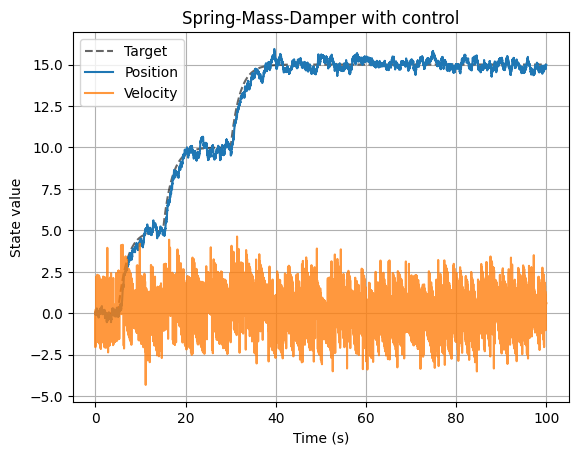

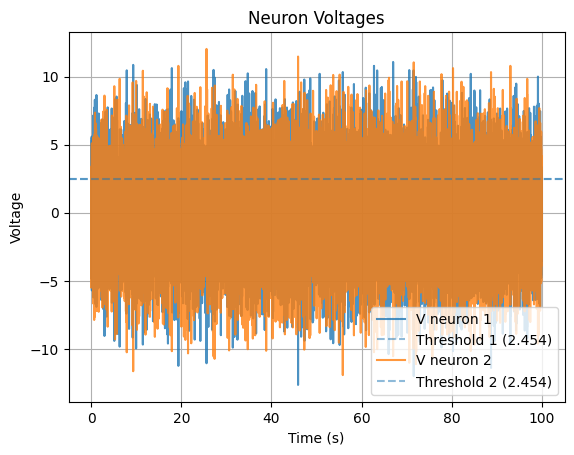

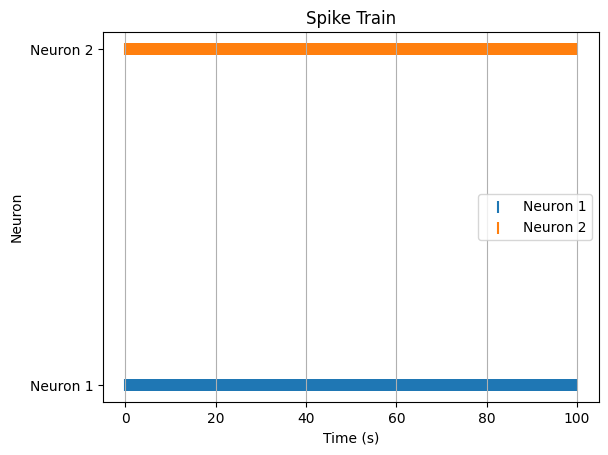

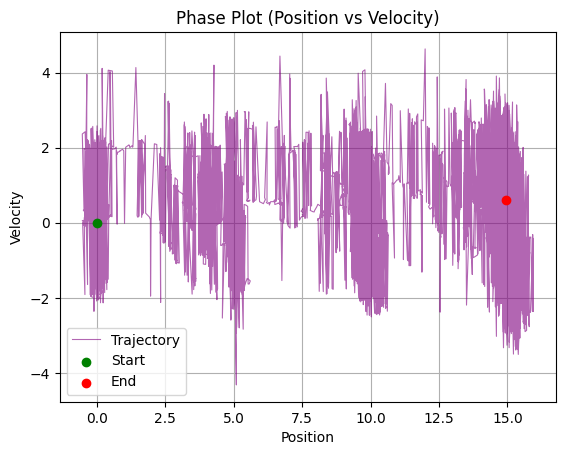

In [10]:
plt.plot(t_eval, z, 'k--', alpha=0.6, label="Target")
plt.plot(t_eval, x[:, 0], label="Position")
plt.plot(t_eval, x[:, 1], alpha=0.8, label="Velocity")
plt.xlabel("Time (s)")
plt.ylabel("State value")
plt.title("Spring-Mass-Damper with control")
plt.legend()
plt.grid()
plt.show()

plt.figure()
for j in range(N):
    plt.plot(t_eval, V_history[:, j], alpha=0.8, label=f"V neuron {j+1}")
    plt.axhline(thresholds[j], linestyle='--', alpha=0.5,
                label=f"Threshold {j+1} ({thresholds[j]:.3f})")
plt.xlabel("Time (s)")
plt.ylabel("Voltage")
plt.title("Neuron Voltages")
plt.legend()
plt.grid()
plt.show()

plt.figure()
for j in range(N):
    spike_times = t_eval[s_history[:, j] == 1.0]
    plt.scatter(spike_times, np.full_like(spike_times, j + 1),
                marker='|', s=80, label=f"Neuron {j+1}")
plt.xlabel("Time (s)")
plt.ylabel("Neuron")
plt.title("Spike Train")
plt.yticks(range(1, N + 1), [f"Neuron {j+1}" for j in range(N)])
plt.legend()
plt.grid(axis='x')
plt.show()

plt.figure()
plt.plot(x[:, 0], x[:, 1], color='purple', alpha=0.6, linewidth=0.8, label="Trajectory")
plt.scatter(x[0, 0], x[0, 1], color='green', zorder=5, label="Start")
plt.scatter(x[-1, 0], x[-1, 1], color='red', zorder=5, label="End")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Phase Plot (Position vs Velocity)")
plt.legend()
plt.grid()
plt.show()

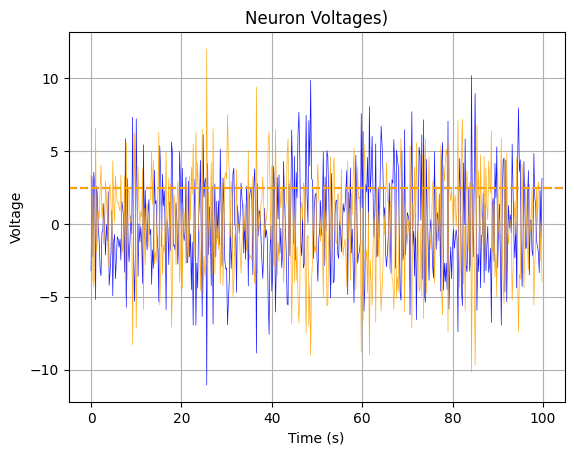

In [11]:
decimate = 20
colors = ['blue','orange']
bin_size = 1.0

for j in range(N):
    plt.plot(t_eval[::decimate], V_history[::decimate, j],
                 color=colors[j], linewidth=0.5, alpha=0.9, label=f"V neuron {j+1}")
    plt.axhline(thresholds[j], linestyle='--', color=colors[j],
                    label=f"Threshold {j+1} ({thresholds[j]:.3f})")
plt.title(f"Neuron Voltages)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage")
plt.grid()
plt.show()

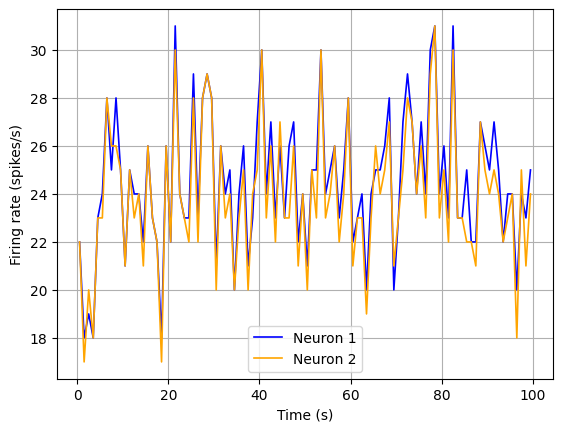

In [12]:
plt.figure()

bins = np.arange(0, T + bin_size, bin_size)
bin_centres = bins[:-1] + bin_size / 2
for j in range(N):
    spike_times = t_eval[s_history[:, j] == 1.0]
    counts, _ = np.histogram(spike_times, bins=bins)
    plt.plot(bin_centres, counts / bin_size,
                 color=colors[j], linewidth=1.2, label=f"Neuron {j+1}")
plt.xlabel("Time (s)")
plt.ylabel("Firing rate (spikes/s)")
plt.legend()
plt.grid()

plt.show()